# WriteLens - EDA

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings
sns.set_style('darkgrid')
warnings.filterwarnings('ignore')

## Load Data

**DAIGT v2** -- sumber: Kaggle train_v2_drcat_02.csv  
Label:  
0 = human  
1 = AI

In [ ]:
daigt = pd.read_csv("train_v2_drcat_02.csv")
daigt.info()
daigt.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 44868 entries, 0 to 44867
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   text           44868 non-null  str  
 1   label          44868 non-null  int64
 2   prompt_name    44868 non-null  str  
 3   source         44868 non-null  str  
 4   RDizzl3_seven  44868 non-null  bool 
dtypes: bool(1), int64(1), str(3)
memory usage: 98.0 MB


,text,label,prompt_name,source,RDizzl3_seven
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus,False
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus,False
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus,False


In [26]:
daigt['label'].value_counts()

label
0    27371
1    17497
Name: count, dtype: int64

**MAGE** --> train + test digabung. Rename: src → source.  
Label diinvert karena berbeda dari DAIGT:  
0 (mesin) → 1  
1 (manusia) → 0. 

In [ ]:
mage_train = pd.read_csv("mage_train.csv")
mage_test  = pd.read_csv("mage_test.csv")

mage = pd.concat([mage_train, mage_test], ignore_index=True)
mage = mage.rename(columns={'src': 'source'})
mage['label'] = 1 - mage['label']

print(mage.shape)
mage['label'].value_counts()

(379814, 4)


label
1    256231
0    123583
Name: count, dtype: int64

Sanity check: source yang mengandung kata human harus berlabel 0 setelah invert.

In [ ]:
mage[mage['source'].str.contains('human', na=False)][['source','label']].head()

,source,label
0,cmv_human,0
1,cmv_human,0
2,cmv_human,0
3,cmv_human,0
4,cmv_human,0


## Statistik Dasar

Kolom turunan yang ditambahkan: word_count, char_count, sentence_count, 
avg_word_length.

In [29]:
for df in [daigt, mage]:
    df['word_count']     = df['text'].apply(lambda x: len(str(x).split()))
    df['char_count']     = df['text'].apply(lambda x: len(str(x)))
    df['sentence_count'] = df['text'].apply(lambda x: len([s for s in re.split(r'[.!?]+', str(x)) if s.strip()]))
    df['avg_word_length'] = df['text'].apply(
        lambda x: np.mean([len(w) for w in re.findall(r"[A-Za-z']+", str(x))]) if re.findall(r"[A-Za-z']+", str(x)) else 0
    )

In [30]:
daigt.groupby('label')[['word_count','sentence_count','avg_word_length']].describe().T

label                             0             1
word_count      count  27371.000000  17497.000000
                mean     418.283146    329.398983
                std      189.285918     94.256529
                min      143.000000      4.000000
                25%      274.000000    274.000000
                50%      383.000000    328.000000
                75%      519.000000    386.000000
                max     1656.000000    818.000000
sentence_count  count  27371.000000  17497.000000
                mean      21.428921     18.403098
                std       10.072558      6.437283
                min        1.000000      1.000000
                25%       14.000000     14.000000
                50%       20.000000     18.000000
                75%       27.000000     22.000000
                max      135.000000     63.000000
avg_word_length count  27371.000000  17497.000000
                mean       4.427488      4.933824
                std        0.308070      0.467134
                min        3.175824      1.024096
                25%        4.212933      4.615873
                50%        4.421849      4.919643
                75%        4.637766      5.255422
                max        6.156504      7.000000

In [31]:
mage.groupby('label')[['word_count','sentence_count','avg_word_length']].describe().T

label                              0              1
word_count      count  123583.000000  256231.000000
                mean      198.370415     218.424301
                std       255.474201     237.979805
                min         6.000000       6.000000
                25%        61.000000      52.000000
                50%       121.000000     114.000000
                75%       228.000000     276.000000
                max     10129.000000    1770.000000
sentence_count  count  123583.000000  256231.000000
                mean       13.206234      14.076076
                std        18.683468      19.228515
                min         1.000000       1.000000
                25%         4.000000       3.000000
                50%         7.000000       6.000000
                75%        14.000000      15.000000
                max       618.000000     483.000000
avg_word_length count  123583.000000  256231.000000
                mean        4.583692       4.661686
                std         0.532911       0.585910
                min         0.000000       1.339713
                25%         4.196721       4.242424
                50%         4.500000       4.613636
                75%         4.906154       5.031250
                max         8.096774       8.967480

## Distribusi Label

DAIGT: ~61% human / 39% AI. MAGE: ~33% human / 67% AI.

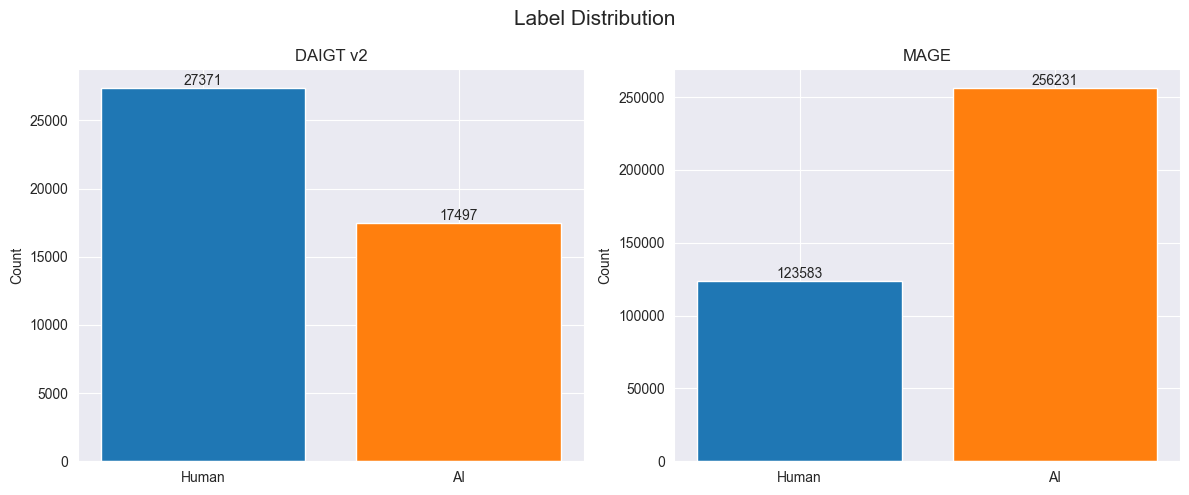

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, title in [(axes[0], daigt, "DAIGT v2"), (axes[1], mage, "MAGE")]:
    counts = df['label'].value_counts().sort_index()
    ax.bar(['Human', 'AI'], [counts[0], counts[1]], color=['tab:blue', 'tab:orange'])
    ax.set_title(title)
    ax.set_ylabel("Count")
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v, str(v), ha='center', va='bottom')

fig.suptitle("Label Distribution", fontsize=15)
plt.tight_layout()
plt.show()

## Panjang Teks

Word count diclip di 2000 kata. Garis putus-putus = median per label.

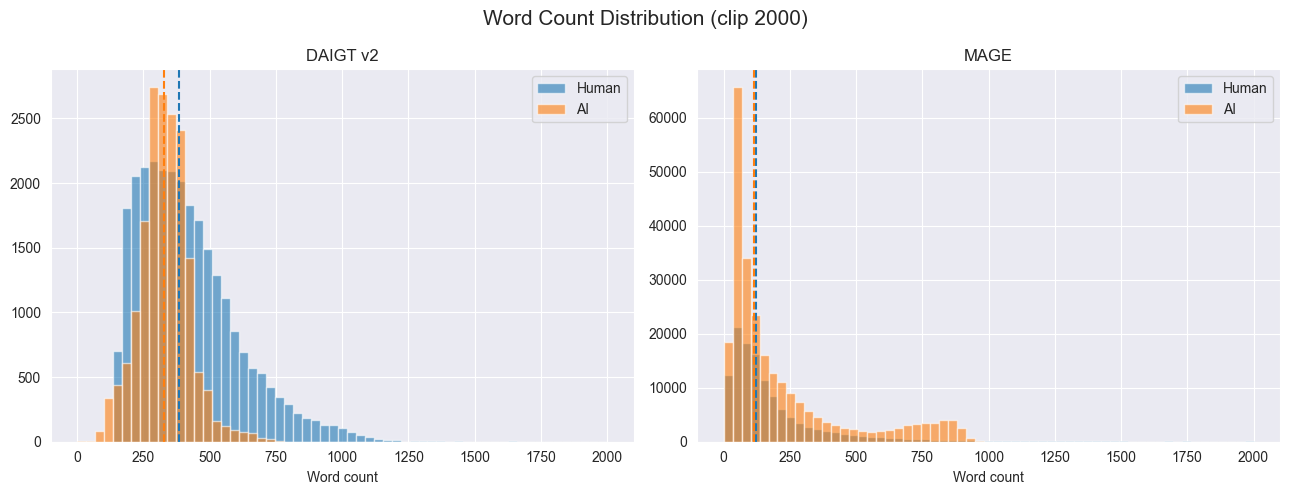

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
XCLIP = 2000

for ax, df, title in [(axes[0], daigt, "DAIGT v2"), (axes[1], mage, "MAGE")]:
    h = df.loc[df['label']==0, 'word_count']
    a = df.loc[df['label']==1, 'word_count']
    bins = np.linspace(0, XCLIP, 60)
    ax.hist(h.clip(upper=XCLIP), bins=bins, color='tab:blue', alpha=0.6, label='Human')
    ax.hist(a.clip(upper=XCLIP), bins=bins, color='tab:orange', alpha=0.6, label='AI')
    ax.axvline(h.median(), color='tab:blue', ls='--')
    ax.axvline(a.median(), color='tab:orange', ls='--')
    ax.set_title(title)
    ax.set_xlabel("Word count")
    ax.legend()

fig.suptitle("Word Count Distribution (clip 2000)", fontsize=15)
plt.tight_layout()
plt.show()

Box plot word count per label. Clip di 3000 kata.

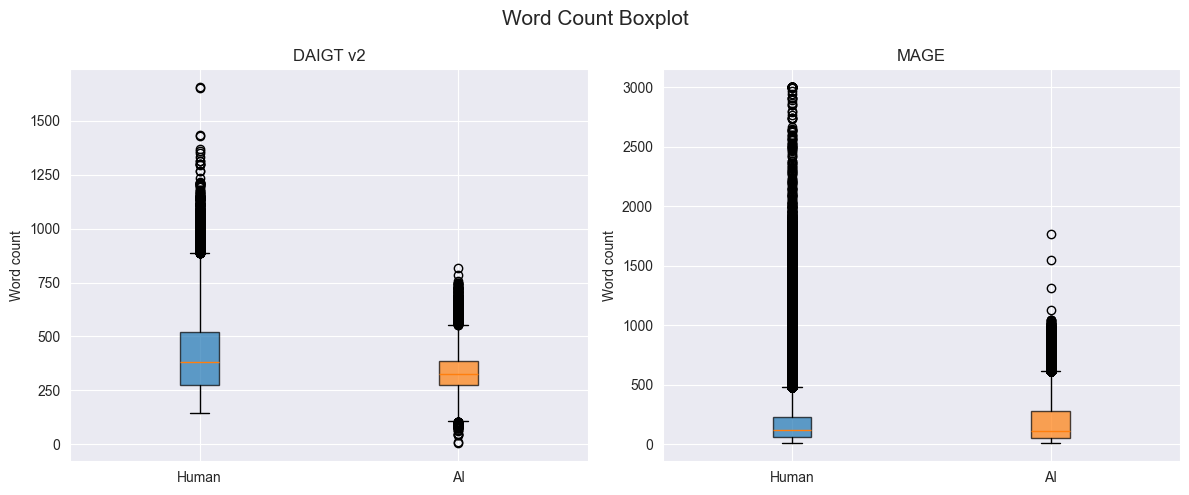

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, title in [(axes[0], daigt, "DAIGT v2"), (axes[1], mage, "MAGE")]:
    d = [df.loc[df['label']==0,'word_count'].clip(upper=3000),
         df.loc[df['label']==1,'word_count'].clip(upper=3000)]
    bp = ax.boxplot(d, labels=['Human','AI'], patch_artist=True)
    for patch, c in zip(bp['boxes'], ['tab:blue', 'tab:orange']):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_ylabel("Word count")

fig.suptitle("Word Count Boxplot", fontsize=15)
plt.tight_layout()
plt.show()

Histogram sentence count per label. Clip di 120 kalimat.

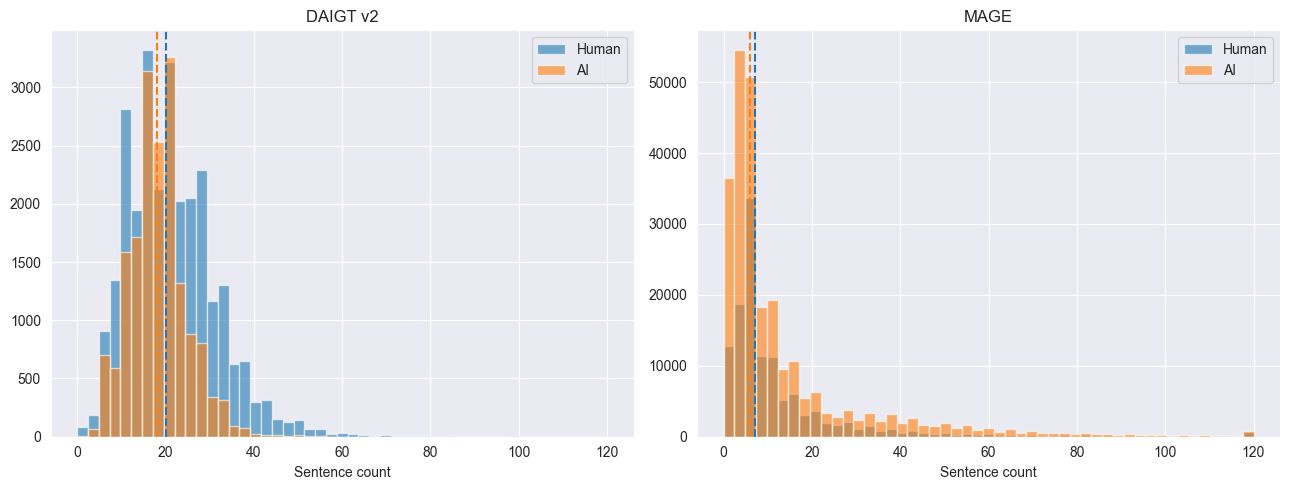

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
XCLIP = 120

for ax, df, title in [(axes[0], daigt, "DAIGT v2"), (axes[1], mage, "MAGE")]:
    h = df.loc[df['label']==0, 'sentence_count']
    a = df.loc[df['label']==1, 'sentence_count']
    bins = np.linspace(0, XCLIP, 50)
    ax.hist(h.clip(upper=XCLIP), bins=bins, color='tab:blue', alpha=0.6, label='Human')
    ax.hist(a.clip(upper=XCLIP), bins=bins, color='tab:orange', alpha=0.6, label='AI')
    ax.axvline(h.median(), color='tab:blue', ls='--')
    ax.axvline(a.median(), color='tab:orange', ls='--')
    ax.set_title(title)
    ax.set_xlabel("Sentence count")
    ax.legend()

plt.tight_layout()
plt.show()

## Source MAGE

Sumber teks MAGE: berbagai platform (Reddit, Yelp, Wikipedia, QA) dan berbagai model LLM. Top 25 source diurutkan berdasarkan jumlah sampel.

Unique source: 338


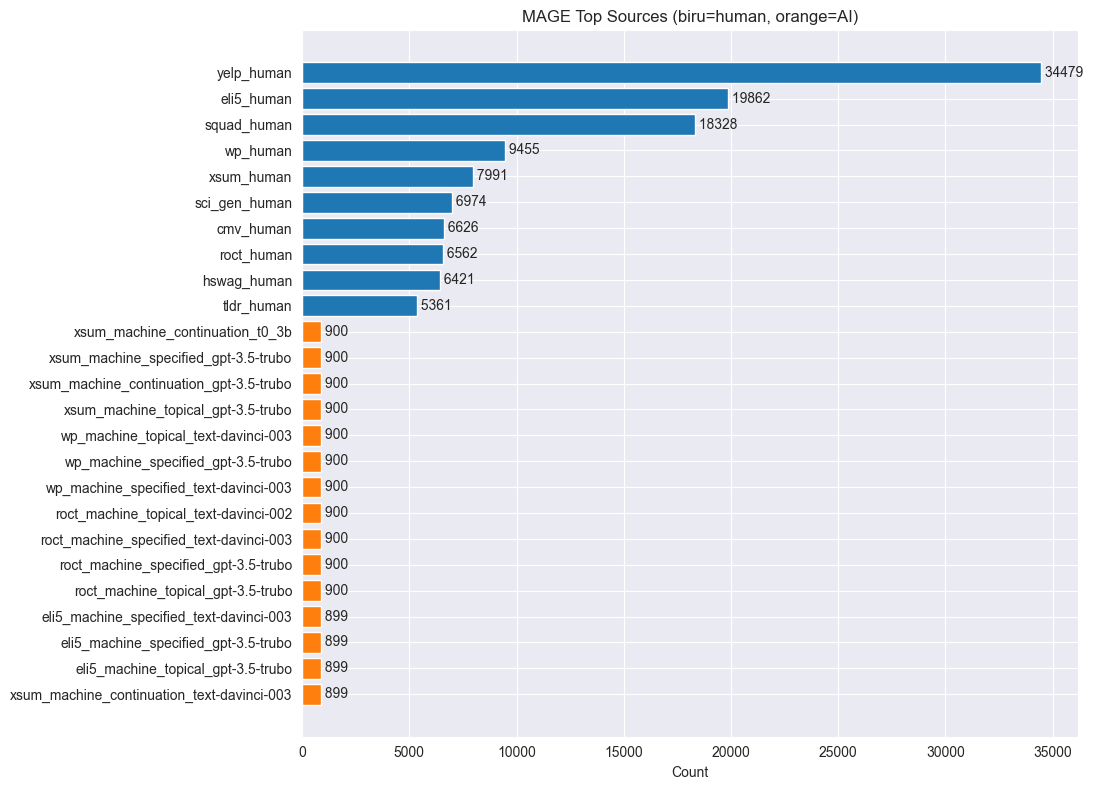

In [36]:
src_counts = mage['source'].value_counts()
print("Unique source:", len(src_counts))

def is_human_src(s):
    return 'human' in str(s).lower()

top_n = min(25, len(src_counts))
top = src_counts.head(top_n).iloc[::-1]
colors = ['tab:blue' if is_human_src(s) else 'tab:orange' for s in top.index]

fig, ax = plt.subplots(figsize=(11, max(6, top_n*0.32)))
ax.barh(top.index, top.values, color=colors)
ax.set_xlabel("Count")
ax.set_title("MAGE Top Sources (biru=human, orange=AI)")
for i, v in enumerate(top.values):
    ax.text(v, i, " " + str(v), va='center')
plt.tight_layout()
plt.show()

Word count per source (top 15), diurutkan berdasarkan median. Clip di 2000 kata.

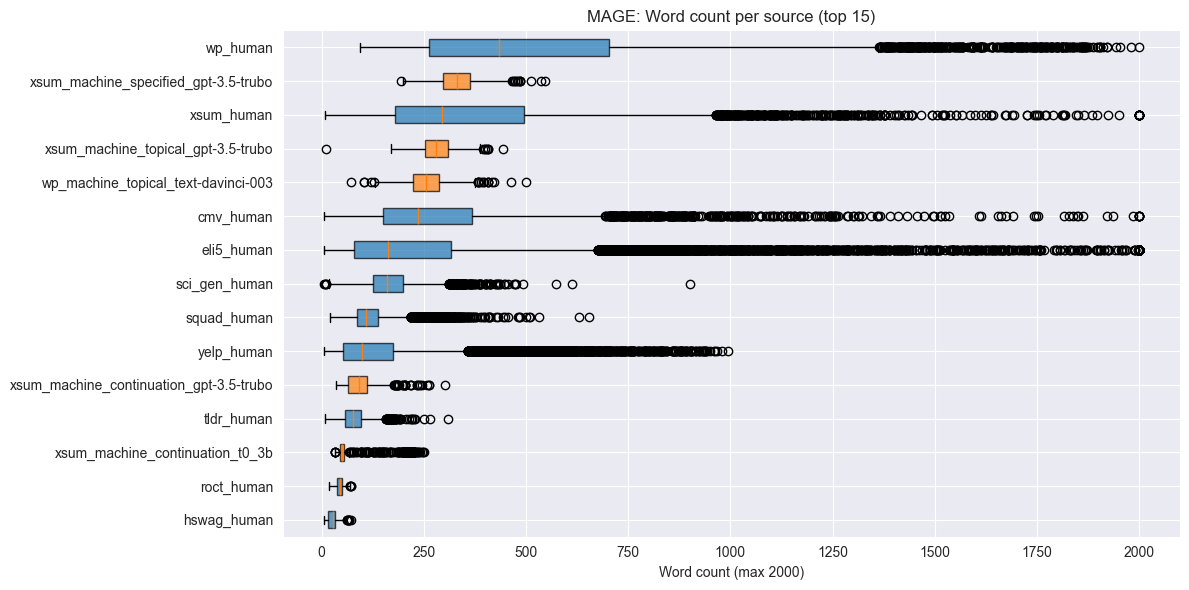

In [37]:
# word count per source top 15
top_sources = mage['source'].value_counts().head(15).index.tolist()
sub = mage[mage['source'].isin(top_sources)].copy()
sub['wc_clip'] = sub['word_count'].clip(upper=2000)

order = sub.groupby('source')['wc_clip'].median().sort_values().index.tolist()
data = [sub.loc[sub['source']==s, 'wc_clip'].values for s in order]
colors = ['tab:blue' if is_human_src(s) else 'tab:orange' for s in order]

fig, ax = plt.subplots(figsize=(12, max(6, len(order)*0.4)))
bp = ax.boxplot(data, labels=order, vert=False, patch_artist=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_xlabel("Word count (max 2000)")
ax.set_title("MAGE: Word count per source (top 15)")
plt.tight_layout()
plt.show()

## Contoh Teks

2 sampel acak per label dari DAIGT v2, dipotong di 400 karakter.

In [38]:
for label, name in [(0, "HUMAN"), (1, "AI")]:
    samp = daigt[daigt['label']==label].sample(2, random_state=42)
    for _, row in samp.iterrows():
        print(f"=== {name} ({row['word_count']} words) ===")
        print(str(row['text'])[:400], "...")
        print()

=== HUMAN (279 words) ===
Are you looking for something to do in your life? If your are then you should join the Seagoing Cowboy program. At first you will have a meloncoly demeanor,but you will get use to traveling and being away from home. The animals you take care of will give you an exubernt feeling. Also, you will be able to vist many different places around the world. You will have alot of fun with to people you meet ...

=== HUMAN (534 words) ===
Dear principal,

It has come to attention that you are considering changing school policy so that students may not participate in sport of other activities unless they have at least a grade B average. Of course, many students have a C average. It is my opinion that students should be allowed to play sports even thought they have a C average. I have many reasons for this, extra curricular activitie ...

=== AI (353 words) ===
 Companies often have a set of criteria they look for in potential employees. Some people believe that companies 

## Cleaning

Kondisi data sebelum cleaning: duplikat, teks pendek (< 20 kata), teks panjang (> 5000 kata), nilai null.

In [ ]:
for name, df in [("DAIGT", daigt), ("MAGE", mage)]:
    dupes = df['text'].duplicated().sum()
    short = (df['word_count'] < 20).sum()
    long  = (df['word_count'] > 5000).sum()
    null  = df['text'].isnull().sum()
    print(f"{name}: {len(df)} rows, {dupes} dupes, {short} short, {long} long, {null} null")

DAIGT: 44868 rows, 0 dupes, 2 short, 0 long, 0 null
MAGE: 379814 rows, 762 dupes, 7057 short, 14 long, 0 null


Langkah cleaning: drop null/kosong → drop duplikat → filter 20 ≤ word_count ≤ 5000.

In [40]:
def clean_dataset(df, name):
    n0 = len(df)
    df = df.dropna(subset=['text']).copy()
    df = df[df['text'].str.strip().str.len() > 0]
    df = df.drop_duplicates(subset=['text'])
    df = df[(df['word_count'] >= 20) & (df['word_count'] <= 5000)]
    print(f"{name}: {n0} -> {len(df)} (buang {n0-len(df)})")
    return df.reset_index(drop=True)

daigt_clean = clean_dataset(daigt, "DAIGT v2")
mage_clean  = clean_dataset(mage,  "MAGE")

DAIGT v2: 44868 -> 44866 (buang 2)
MAGE: 379814 -> 371981 (buang 7833)


Cek duplikat antar dataset (cross-dataset), bukan hanya dalam satu dataset.

In [ ]:
tmp = pd.concat([daigt_clean[['text']], mage_clean[['text']]], ignore_index=True)
cross_dupes = tmp['text'].duplicated().sum() - daigt_clean['text'].duplicated().sum() - mage_clean['text'].duplicated().sum()
print("Duplikat antar dataset:", cross_dupes)

Duplikat antar dataset: 0


Distribusi label setelah cleaning, verifikasi balance tidak berubah signifikan.

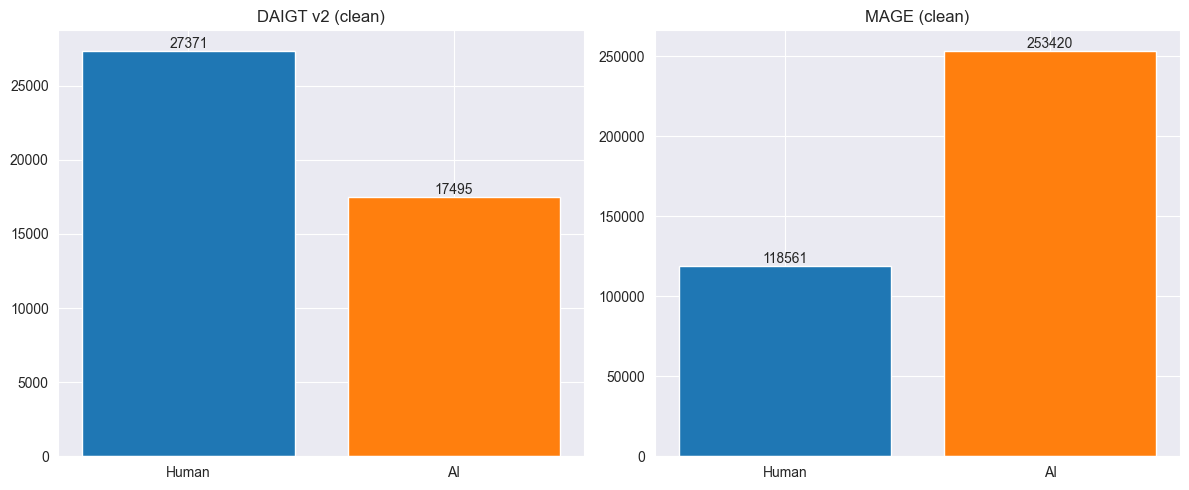

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, title in [(axes[0], daigt_clean, "DAIGT v2 (clean)"), (axes[1], mage_clean, "MAGE (clean)")]:
    c = df['label'].value_counts().sort_index()
    ax.bar(['Human','AI'], [c[0], c[1]], color=['tab:blue', 'tab:orange'])
    ax.set_title(title)
    for i, v in enumerate([c[0], c[1]]):
        ax.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Perbandingan Dataset

Perbandingan total baris, komposisi label (human/AI), dan median word count antar dataset.

In [43]:
combined = pd.concat([daigt_clean, mage_clean], ignore_index=True)

for name, df in [("DAIGT v2", daigt_clean), ("MAGE", mage_clean), ("Combined", combined)]:
    total = len(df)
    h = (df['label']==0).sum()
    a = (df['label']==1).sum()
    print(f"{name}: {total} rows, {h/total*100:.1f}% human, {a/total*100:.1f}% AI, median {int(df['word_count'].median())} words")

DAIGT v2: 44866 rows, 61.0% human, 39.0% AI, median 352 words
MAGE: 371981 rows, 31.9% human, 68.1% AI, median 119 words
Combined: 416847 rows, 35.0% human, 65.0% AI, median 141 words


Gabungan 35/65 imbalance, perlu stratified split + class_weight, DAIGT essay panjang formal, MAGE teks pendek (Reddit/Yelp/QA). Domain beda jauh kalau gabung mentah model bisa belajar 'pendek = AI'

In [ ]:
for name, df in [("DAIGT", daigt_clean), ("MAGE", mage_clean)]:
    for label in [0, 1]:
        med = int(df.loc[df['label']==label, 'word_count'].median())
        print(f"  {name} {'human' if label==0 else 'AI'}: median {med} words")

  DAIGT human: median 383 words
  DAIGT AI: median 328 words
  MAGE human: median 125 words
  MAGE AI: median 116 words


Word count gabungan DAIGT + MAGE. Clip di 2000 kata.

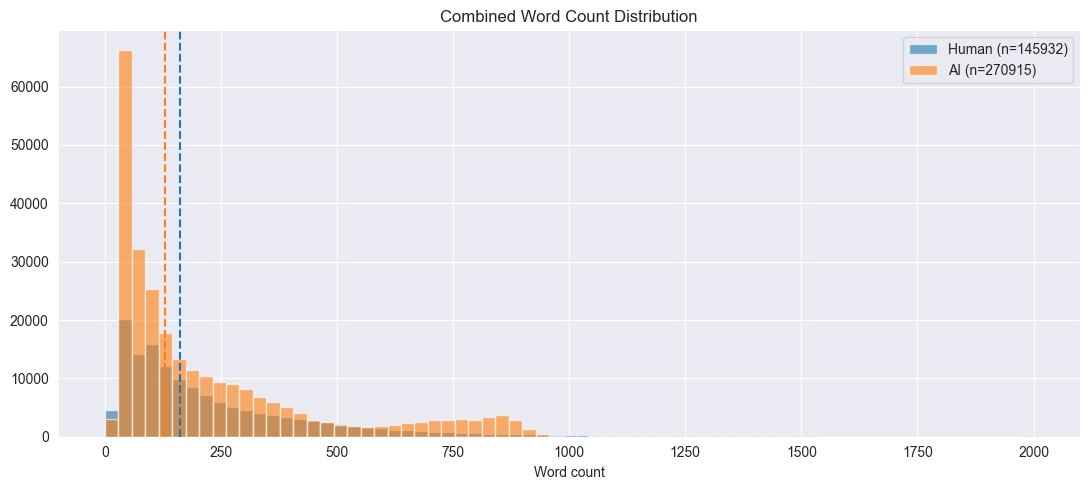

In [45]:
fig, ax = plt.subplots(figsize=(11, 5))
XCLIP = 2000
h = combined.loc[combined['label']==0,'word_count'].clip(upper=XCLIP)
a = combined.loc[combined['label']==1,'word_count'].clip(upper=XCLIP)
bins = np.linspace(0, XCLIP, 70)
ax.hist(h, bins=bins, color='tab:blue', alpha=0.6, label=f"Human (n={len(h)})")
ax.hist(a, bins=bins, color='tab:orange', alpha=0.6, label=f"AI (n={len(a)})")
ax.axvline(h.median(), color='tab:blue', ls='--')
ax.axvline(a.median(), color='tab:orange', ls='--')
ax.set_xlabel("Word count")
ax.set_title("Combined Word Count Distribution")
ax.legend()
plt.tight_layout()
plt.show()

## Simpan

Output: 
daigt_v2_clean.csv,  
mage_clean.csv,  
combined_clean.csv

In [46]:
cols_daigt = [c for c in ['text','label','source','prompt_name'] if c in daigt_clean.columns]
cols_mage  = [c for c in ['text','label','source'] if c in mage_clean.columns]

daigt_out = daigt_clean[cols_daigt].copy()
mage_out  = mage_clean[cols_mage].copy()
daigt_out['dataset'] = 'daigt_v2'
mage_out['dataset']  = 'mage'

daigt_out.to_csv("daigt_v2_clean.csv", index=False)
mage_out.to_csv("mage_clean.csv", index=False)

all_data = pd.concat([daigt_out, mage_out], ignore_index=True)
all_data.to_csv("combined_clean.csv", index=False)

print(f"daigt: {len(daigt_out)}, mage: {len(mage_out)}, combined: {len(all_data)}")

daigt: 44866, mage: 371981, combined: 416847
